# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)

**Paper**: Dobrescu and Shanker, *A fast upper envelope scan method for discrete-continuous dynamic programming*

We solve the housing frictions model of Kaplan and Violante (2014) / Yogo (2016) using two methods. Both use FUES for the keeper's upper envelope; they differ in how the **adjuster stage** inverts the two coupled Euler equations:

| Method | Adjuster stage | UE (keeper) | UE (adjuster) |
|--------|----------------|:-----------:|:-------------:|
| **EGM(FUES)** | Partial EGM: root-find housing FOC, invert consumption FOC analytically | FUES | FUES |
| **NEGM(FUES)** | Golden-section search over $H'$, nesting the keeper's 1D EGM | FUES | — |

The keeper stage (1D EGM + FUES) and the tenure stage (branching max + $\mathbb{E}_z$) are identical under both methods. The comparison isolates the benefit of EGM inversion for the adjuster, where non-monotone housing policies and multiple locally optimal candidates create a dense cloud of crossing value-function segments — a structure that MSS and LTM cannot resolve.

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import time, sys, os, contextlib, io

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables2_0.solve import solve, precompile
from examples.durables2_0.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables2_0.outputs import (
    setup_nb_style,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    get_timing,
    compute_euler_stats, print_euler_stats,
    generate_vertical_comparison,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables2_0/mod/cobb_douglas/'
print('Ready')

Ready


## 1. Model

A household lives for $T$ periods, holding financial assets $a \ge 0$ and housing $H \ge 0$. Financial assets earn return $r$; adjusting housing to $H'$ costs $\tau H'$. Each period the household draws stochastic wage $y$ and makes three decisions:

1. **Tenure choice** $d \in \{0,1\}$: adjust housing ($d=1$) or keep ($d=0$, so $H' = H$).
2. **Consumption** $c$ of non-housing goods.
3. **Portfolio**: next-period assets $a'$ and, if adjusting, new housing $H'$.

The budget constraint for adjusters is

$$m \;\equiv\; (1{+}r)\,a + y + H \;\ge\; a' + c + (1{+}\tau)\,H',$$

where $m$ denotes total wealth. Per-period utility is $u(c, H')$, jointly concave in its arguments.

**Two Euler equations.** The financial-assets FOC is standard: $u_c(c,H') \ge \beta(1{+}r)\,\mathbb{E}\,u_c(c',H'')$. The housing FOC equates the shadow price of investment $(1{+}\tau)\,u_c$ to the marginal value of the housing services stream plus the expected liquidation value at the next adjustment date — a stochastic stopping-time condition.

**Why FUES matters here.** Intertemporal income effects between housing and financial savings produce multiple inverse-Euler roots and non-monotone housing policies. MSS and LTM require monotonicity and cannot be applied. NEGM avoids the issue by nesting a numerical maximisation, but introduces truncation error. EGM(FUES) recovers the full upper envelope from the dense cloud of EGM candidates in a single $O(N)$ pass.

## 2. Solve

We solve the model under both methods. Parameters and grids are loaded from YAML; `setting_overrides` patches grid sizes at runtime.

In [ ]:
results = {}
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

OVERRIDES = dict(
    setting_overrides={'store_cntn': 1, 'N_wage': 6, 'n_w': 600, 'n_a': 600, 'n_h': 900},
    calib_overrides={'t0': 20, 'tau': 0.12, 'sigma_w': 0.15, 'phi_w': 0.86, 'beta': 0.89, 'R': 1.04},
)

# Suppress SCAN DEBUG prints from numba internals but keep tqdm progress bar
_real_stdout = sys.stdout

class _FilteredStdout:
    """Pass everything to real stdout except lines containing SCAN DEBUG."""
    def __init__(self, real):
        self._real = real
    def write(self, s):
        if 'SCAN DEBUG' not in s:
            self._real.write(s)
    def flush(self):
        self._real.flush()

for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = _FilteredStdout(_real_stdout)
    try:
        nest, grids = solve(SYNTAX, method=method, verbose=False,
                            progress='bar', **OVERRIDES)
    finally:
        sys.stdout = _real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {'nest': nest, 'grids': grids,
                       'timing': timing, 'elapsed': elapsed}

# Clean summary
_st = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_cal, _sett = _st.calibration, _st.settings
n_periods = len(results['FUES']['nest']['solutions'])

print(f"\n  {n_periods} periods, ages {int(_cal['t0'])}–{_sett['T']}")
print(f"  beta={_cal['beta']}, R={_cal['R']}, tau={_cal['tau']}, "
      f"gamma_c={_cal['gamma_c']}, gamma_h={_cal['gamma_h']}, alpha={_cal['alpha']}")
print(f"  n_a={_sett['n_a']}, n_h={_sett['n_h']}, n_w={_sett['n_w']}, "
      f"N_wage={_sett['N_wage']}")
print()
print(f"  {'Method':12s}  {'Keeper':>10s}  {'Adjuster':>10s}  {'Tenure':>10s}  {'Total':>8s}")
print(f"  {'':12s}  {'(ms/period)':>10s}  {'(ms/period)':>10s}  {'(ms/period)':>10s}  {'(sec)':>8s}")
print(f"  {'─'*60}")
for method in ['FUES', 'NEGM']:
    t = results[method]['timing']
    print(f"  {labels[method]:12s}  {t['keeper_ms']:10.0f}  {t['adj_ms']:10.0f}  "
          f"{t['discrete_ms']:10.0f}  {results[method]['elapsed']:8.0f}")

EGM(FUES)


Solving:  24%|██▎       | 12/51 [00:41<01:41,  2.59s/it, age=59, avg_adj_ms=191, avg_keeper_ms=976]

## 3. Adjuster policies

Adjuster financial assets $a'$ and housing choice $H'$ as functions of total wealth $m$. The left panel shows savings discontinuities from the discrete tenure choice; the right panel shows the non-monotone housing policy that breaks MSS/LTM.

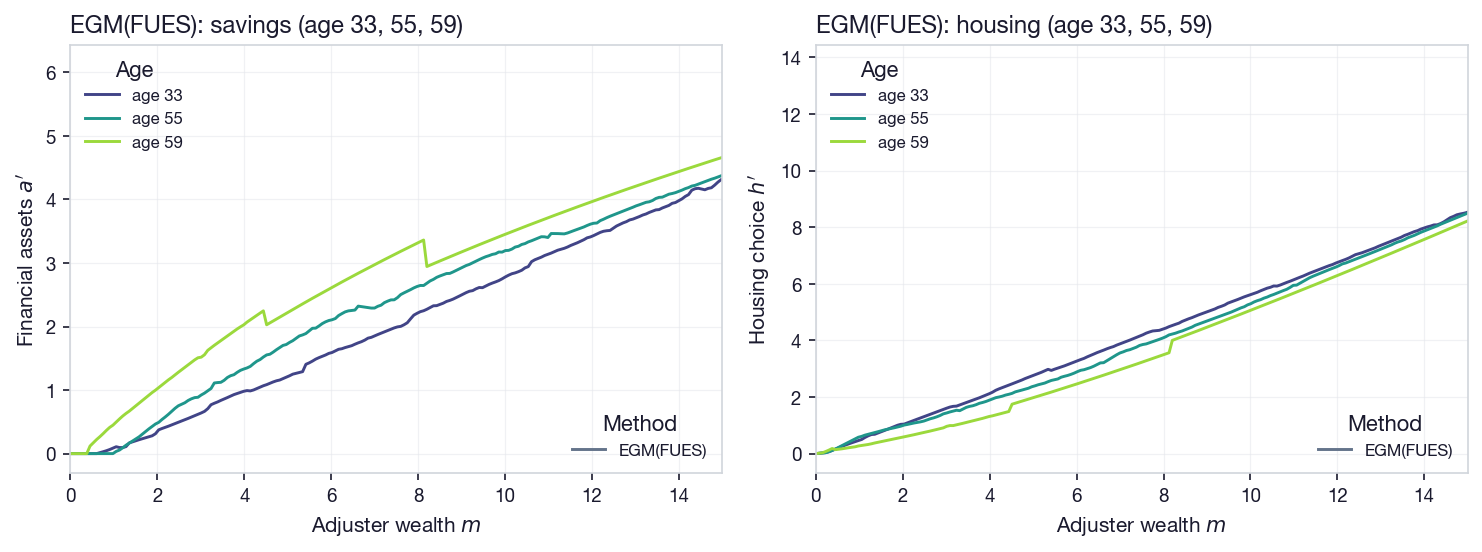

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[33, 55, 59], methods_filter=['FUES'])

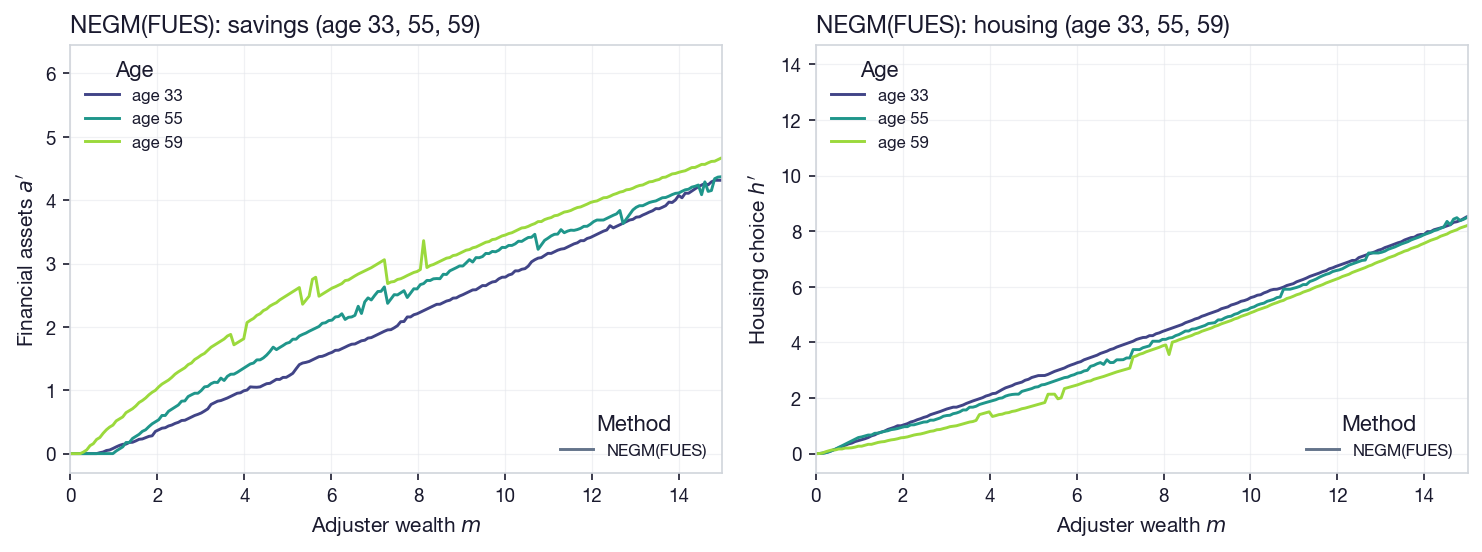

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[33, 55, 59], methods_filter=['NEGM'])

## 4. Adjuster EGM grid

The partial EGM over the $H'$ grid produces an endogenous wealth grid where **multiple housing choices map to the same wealth level**. The left panel shows raw EGM candidates for financial assets $a'$; the right panel shows housing $H'$. Each scatter point is one $(H', a')$ root of the coupled FOCs. FUES scans this dense cloud to recover the upper envelope (solid line) in a single pass. DCEGM's secondary envelope and LTM's local triangulation require locally isolated crossings and cannot resolve this structure.

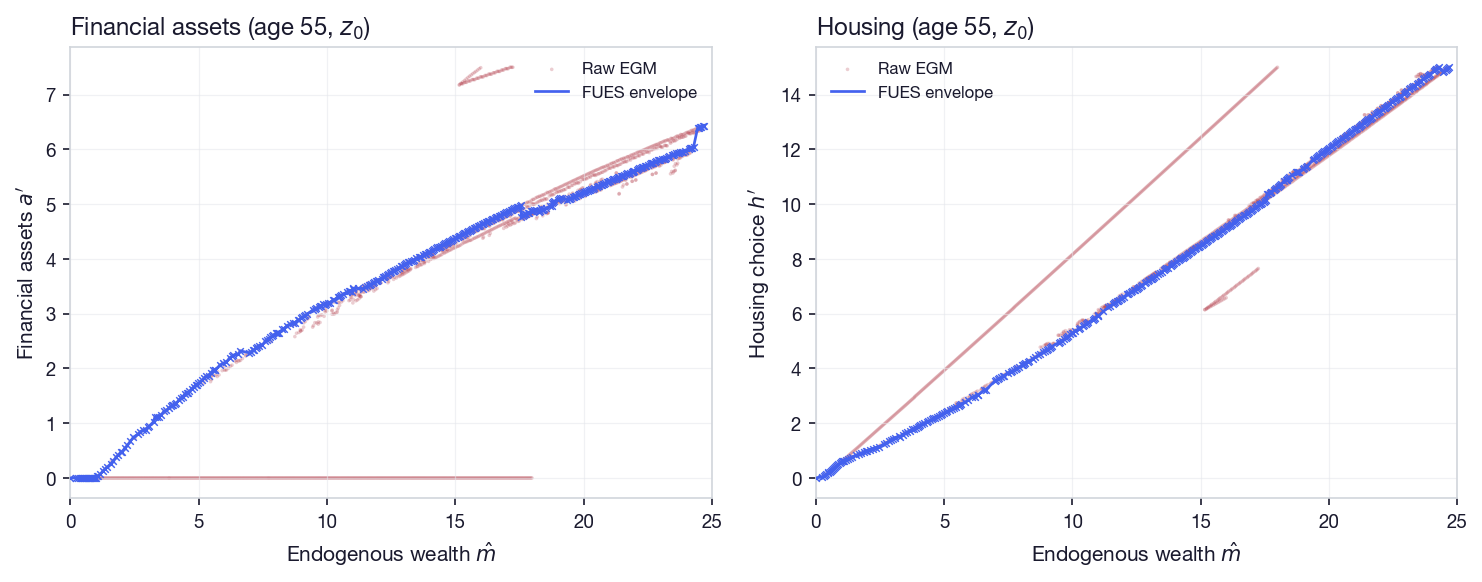

In [ ]:
fig = nb_plot_adjuster_egm(results['FUES']['nest'], results['FUES']['grids'], plot_t=55)

## 5. Keeper policies

Keeper consumption $c$ and savings $a'$ as functions of cash-on-hand $w_\mathrm{keep}$, for a fixed housing level $h$. The keeper has a single control (consumption); housing passes through unchanged. Both methods use the same 1D EGM + FUES kernel, so policies should be nearly identical. Kinks in the continuation value — inherited from the tenure stage's discrete choice — produce non-monotone segments that FUES resolves.

In [ ]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[33, 55, 59])

### Keeper EGM grid

Raw EGM candidates for one $(z, h)$ slice. Unlike the adjuster (where the dense cloud arises from the partial EGM over $H'$), the keeper's non-monotonicity comes from kinks in the continuation value function at wealth thresholds where the **future** tenure choice switches. The constrained region (low wealth) plus the unconstrained EGM points are pooled and refined by FUES.

*Note:* This plot requires the generic EGM path (not the fast FUES kernel). If no EGM data is stored, the cell prints a diagnostic message.

In [ ]:
fig = nb_plot_keeper_egm(results['FUES']['nest'], results['FUES']['grids'], plot_t=33)

## 6. Euler equation errors

We forward-simulate 10,000 agents and evaluate two distinct Euler residuals, measured as $\log_{10}$ relative error ($-4$ = four digits of accuracy).

**Consumption FOC** (all agents): $u_c(c, H') = \beta(1{+}r)\,\mathbb{E}\,u_c(c', H'')$. Since the keeper stage is identical under both methods, keeper errors are similar. The adjuster consumption Euler may differ because it depends on the accuracy of the $H'$ choice.

**Housing FOC** (adjusters only): $(1{+}\tau)\,u_c = u_H(H') + \beta\,\partial_H V_\succ$. This is where the methods diverge. EGM(FUES) inverts this FOC analytically via root-finding; NEGM(FUES) solves it by golden-section search, introducing numerical truncation.

In [ ]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=10_000, seed=42)
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


Left: keeper consumption FOC (methods nearly identical). Right: adjuster housing FOC, where EGM(FUES) gains roughly half an order of magnitude in accuracy over NEGM(FUES).

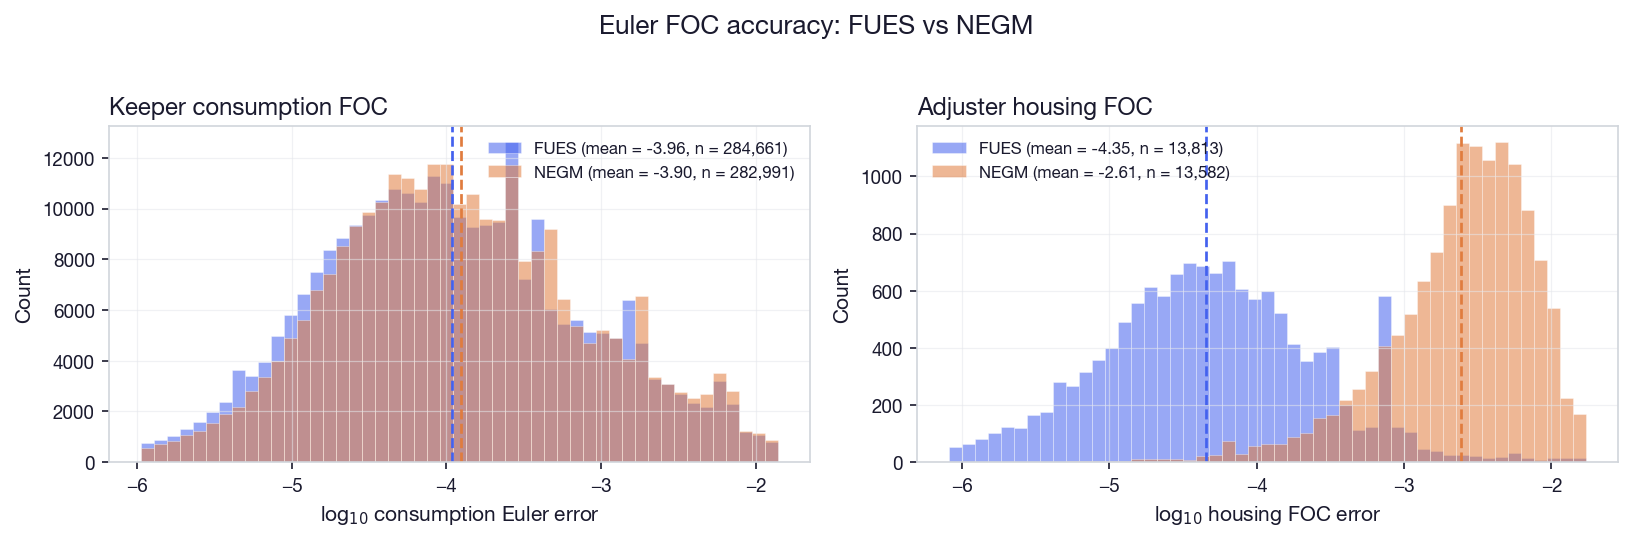

In [ ]:
fig = plot_euler_histogram(euler_results)

## 7. Comparison

In [ ]:
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
rows = []
for method in ['FUES', 'NEGM']:
    t = results[method]['timing']
    row = {
        'Method': labels[method],
        'Keeper (ms)': t['keeper_ms'],
        'Adj (ms)': t['adj_ms'],
        'Total (ms)': t['keeper_ms'] + t['adj_ms'] + t['discrete_ms'],
    }
    ec = euler_results[method]['stats_c']
    eh = euler_results[method]['stats_h']
    if 'combined' in ec:
        row['Euler c (keeper)'] = ec['keeper']['mean']
        row['Euler c (adj)'] = ec['adjuster']['mean']
        row['Euler c (all)'] = ec['combined']['mean']
    if 'combined' in eh:
        row['Euler h (adj)'] = eh['adjuster']['mean']
    sd = euler_results[method]['sim_data']
    d = sd['discrete']
    row['Adj Rate'] = np.mean(d[d >= 0]) * 100
    rows.append(row)

Markdown(generate_vertical_comparison(rows, caption='EGM(FUES) vs NEGM(FUES)'))

### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 188 | 190 |
| Adjuster (ms/period) | 17 | 52 |
| Total (ms/period) | 580 | 647 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -3.96 | -3.90 |
| Consumption: adjuster | -3.41 | -3.61 |
| Consumption: all | -3.94 | -3.89 |
| Housing: adjuster | -4.35 | -2.61 |
| **Simulation** |  |  |
| Adjustment rate (%) | 14.3 | 14.5 |

## 8. Lifecycle profiles

Mean consumption, financial assets, and housing over the lifecycle. Both methods produce nearly identical aggregate profiles, confirming that the policy differences are localised to the adjuster's housing FOC.

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


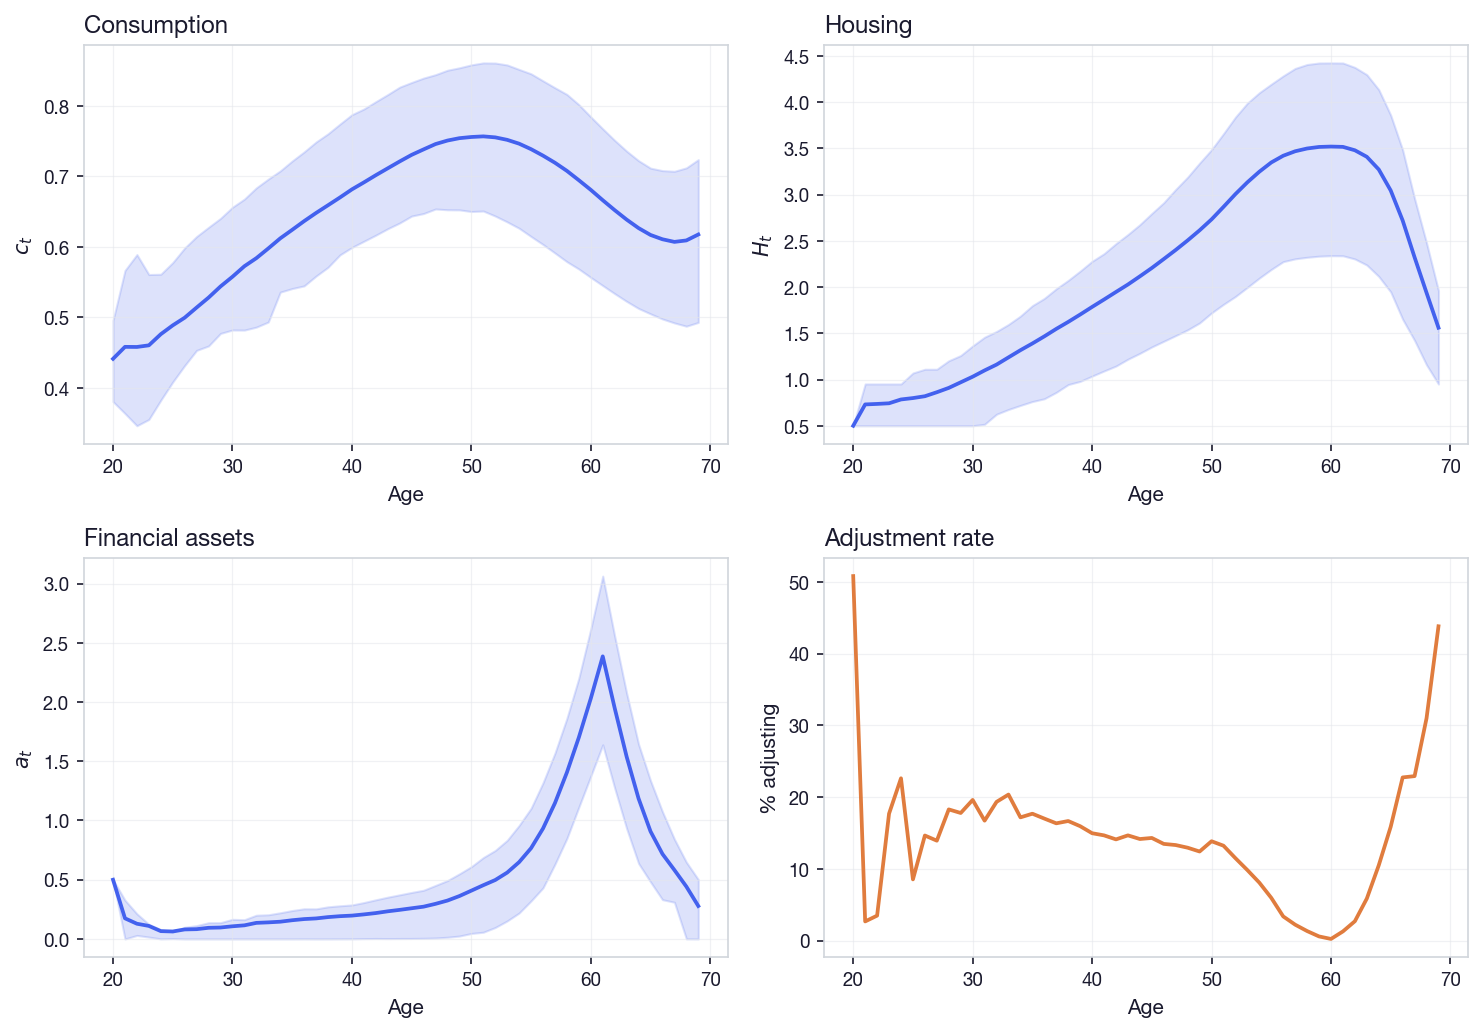

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


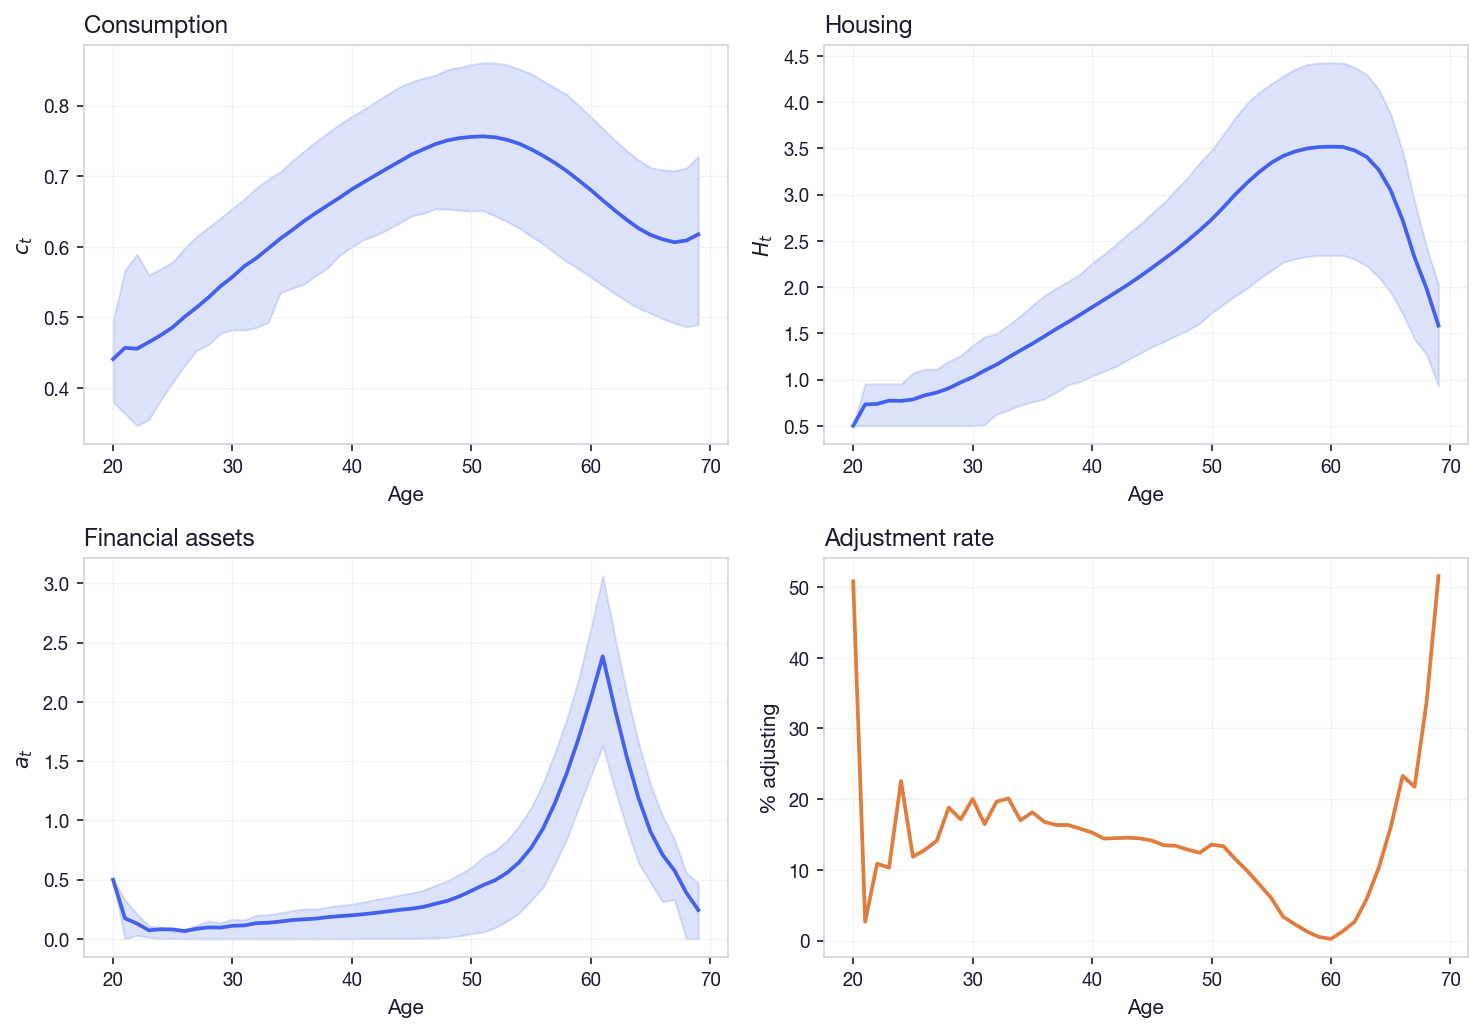

In [ ]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

Simulation moments by 5-year age cohort. Mean and standard deviation of consumption, financial assets, and housing across 10,000 agents.

In [ ]:
def _cohort_table(sim_data, t0, T, norm, cohort_width=5):
    """Mean and SD by 5-year cohort for c, a, h (in $)."""
    bins = list(range(t0, T, cohort_width))
    if bins[-1] < T:
        bins.append(T)
    rows = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        label = f'{lo}\u2013{hi - 1}'
        row = {'Age': label}
        for key, name in [('c', 'Consumption'), ('a', 'Financial assets'), ('h', 'Housing')]:
            panel = sim_data[key][lo:hi, :] * norm
            vals = panel[np.isfinite(panel)]
            if len(vals) > 0:
                row[f'{name} mean'] = np.mean(vals)
                row[f'{name} SD'] = np.std(vals)
            else:
                row[f'{name} mean'] = np.nan
                row[f'{name} SD'] = np.nan
        rows.append(row)
    return rows

_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])

def _fmt(v):
    """Format dollar value with commas and 2 decimal places."""
    if np.isnan(v):
        return '\u2014'
    return f'{v:,.2f}'

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    cohort_rows = _cohort_table(sd, _t0, _T, _norm)

    hdr = '| Age | $\\bar{c}$ | SD($c$) | $\\bar{a}$ | SD($a$) | $\\bar{H}$ | SD($H$) |'
    sep = '|:---|---:|---:|---:|---:|---:|---:|'
    lines = [f'**{labels[method]}**\n', hdr, sep]
    for r in cohort_rows:
        lines.append(
            f'| {r["Age"]} '
            f'| {_fmt(r["Consumption mean"])} | {_fmt(r["Consumption SD"])} '
            f'| {_fmt(r["Financial assets mean"])} | {_fmt(r["Financial assets SD"])} '
            f'| {_fmt(r["Housing mean"])} | {_fmt(r["Housing SD"])} |'
        )
    display(Markdown('\n'.join(lines)))

**EGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 45,885.60 | 10,716.03 | 19,567.19 | 19,006.05 | 69,883.81 | 27,092.84 |
| 25–29 | 51,486.11 | 13,468.97 | 8,326.93 | 13,825.03 | 87,221.39 | 51,332.14 |
| 30–34 | 58,480.07 | 14,237.59 | 12,855.49 | 19,085.55 | 116,951.59 | 73,245.93 |
| 35–39 | 64,752.90 | 14,853.95 | 17,508.76 | 24,132.20 | 154,616.94 | 91,945.05 |
| 40–44 | 70,135.24 | 15,329.74 | 22,027.35 | 29,481.08 | 194,840.32 | 108,973.48 |
| 45–49 | 74,379.15 | 15,352.54 | 30,282.57 | 37,750.62 | 240,612.14 | 126,776.93 |
| 50–54 | 75,307.88 | 16,018.29 | 51,359.57 | 50,798.42 | 299,733.95 | 147,693.50 |
| 55–59 | 71,780.91 | 17,109.70 | 119,084.43 | 79,769.73 | 345,052.11 | 158,973.00 |
| 60–64 | 65,282.83 | 16,277.90 | 181,788.09 | 100,389.16 | 343,953.00 | 159,940.15 |
| 65–69 | 61,225.59 | 16,106.53 | 58,549.55 | 50,208.64 | 231,712.70 | 136,265.08 |

**NEGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 45,864.97 | 10,701.57 | 19,175.78 | 18,671.34 | 70,138.42 | 27,172.52 |
| 25–29 | 51,479.28 | 13,465.71 | 8,503.18 | 14,282.10 | 86,962.80 | 50,682.92 |
| 30–34 | 58,466.20 | 14,212.35 | 12,827.83 | 18,945.40 | 116,785.76 | 73,074.53 |
| 35–39 | 64,757.04 | 14,858.58 | 17,475.34 | 24,159.02 | 154,500.93 | 91,807.63 |
| 40–44 | 70,151.52 | 15,324.26 | 22,132.56 | 29,632.42 | 194,570.50 | 108,727.83 |
| 45–49 | 74,395.16 | 15,342.92 | 30,087.70 | 37,430.42 | 240,445.98 | 126,766.15 |
| 50–54 | 75,306.89 | 15,992.11 | 51,238.81 | 50,585.33 | 299,487.98 | 147,904.93 |
| 55–59 | 71,754.56 | 17,074.70 | 118,913.71 | 79,422.91 | 344,878.81 | 159,572.46 |
| 60–64 | 65,261.56 | 16,249.22 | 181,751.73 | 100,234.50 | 343,734.04 | 160,360.66 |
| 65–69 | 61,218.75 | 16,104.29 | 56,558.97 | 50,488.07 | 233,173.17 | 135,138.49 |

## 9. Runtime overrides

All parameters come from YAML stage definitions. Override calibration or grid sizes at runtime without editing files.

In [ ]:
nest_ov, grids_ov = solve(
    SYNTAX, method='FUES',
    calib_overrides={'tau': 0.25},
    setting_overrides={'n_a': 100, 'n_h': 100, 'n_w': 100},
    verbose=False)

_keeper_ov = nest_ov["periods"][0]["stages"]["keeper_cons"]
timing_ov = get_timing(nest_ov)
print(f'tau = {_keeper_ov.calibration["tau"]}, '
      f'n_a = {len(grids_ov["a"])}, '
      f'{len(nest_ov["solutions"])} periods, '
      f'keeper {timing_ov["keeper_ms"]:.0f} ms, '
      f'adj {timing_ov["adj_ms"]:.0f} ms')

tau = 0.25, n_a = 100, 31 periods, keeper 9 ms, adj 1 ms


---

*Source: `examples/durables2_0/` — Dobrescu and Shanker (2026), Application 2*